In [4]:
import pickle
import numpy as np
import pandas as pd

from score_utils import ms, pd_to_score, score_to_rating

# ── Path ──────────────────────────────────────────────────────────────────────
DF_PATH    = r"D:\KL-lieuvth2\df_woe_long_list.csv"
MODEL_PATH = r"D:\KL-lieuvth2\model.pkl"

ID_COL      = "SK_ID_CURR"
TARGET_COL  = "TARGET"
DATASET_COL = "flag_train_test"

# ── Read data + model ─────────────────────────────────────────────────────────
df = pd.read_csv(DF_PATH)

with open(MODEL_PATH, "rb") as f:
    model = pickle.load(f)

# ── Lấy feature có trong model ────────────────────────────────────────────────
model_features = [
    col for col in model.params.index
    if col != "const"
]

missing = [col for col in model_features if col not in df.columns]
if missing:
    raise ValueError(f"Missing features: {missing}")

# ── Tạo X đúng thứ tự model ───────────────────────────────────────────────────
X = df[model_features].copy()

if "const" in model.params.index:
    X.insert(0, "const", 1.0)

# ── Predict PD ─────────────────────────────────────────────────────────────────
df["PD"] = model.predict(X)

# ── PD → Log-odds ──────────────────────────────────────────────────────────────
df["logodd"] = np.log(df["PD"] / (1 - df["PD"]))

# ── PD → Score ─────────────────────────────────────────────────────────────────
df = pd_to_score(
    df,
    col_pd="PD",
    col_score="Score"
)

# ── Score → Rating ────────────────────────────────────────────────────────────
df = score_to_rating(
    df,
    ms,
    col_score="Score",
    col_rating="Rating"
)

# ── Kết quả ───────────────────────────────────────────────────────────────────
result_cols = [
    ID_COL,
    TARGET_COL,
    DATASET_COL,
    "PD",
    "logodd",
    "Score",
    "Rating"
]

print(df[result_cols].head())

   SK_ID_CURR  TARGET flag_train_test        PD    logodd       Score Rating
0      100002       1           train  0.238417 -1.161375  500.791358     D2
1      100003       0           train  0.026093 -3.619663  589.455344     B3
2      100004       0           train  0.019351 -3.925450  600.484275     B1
3      100006       0            test  0.051601 -2.911238  563.904320     C2
4      100007       0           train  0.089607 -2.318438  542.523560     D1


In [5]:
df.to_csv(r'scorecard_pred.csv')

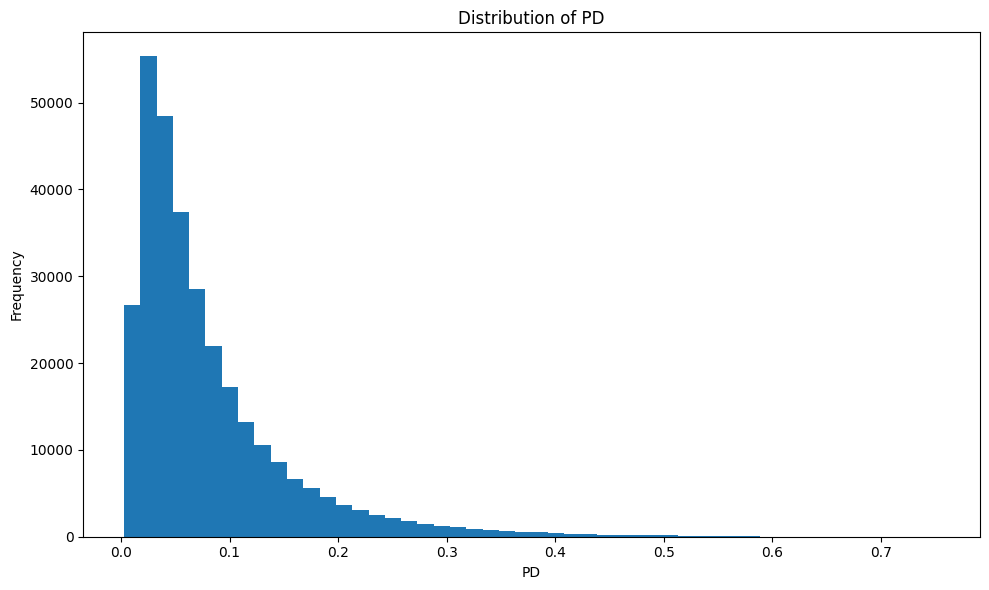

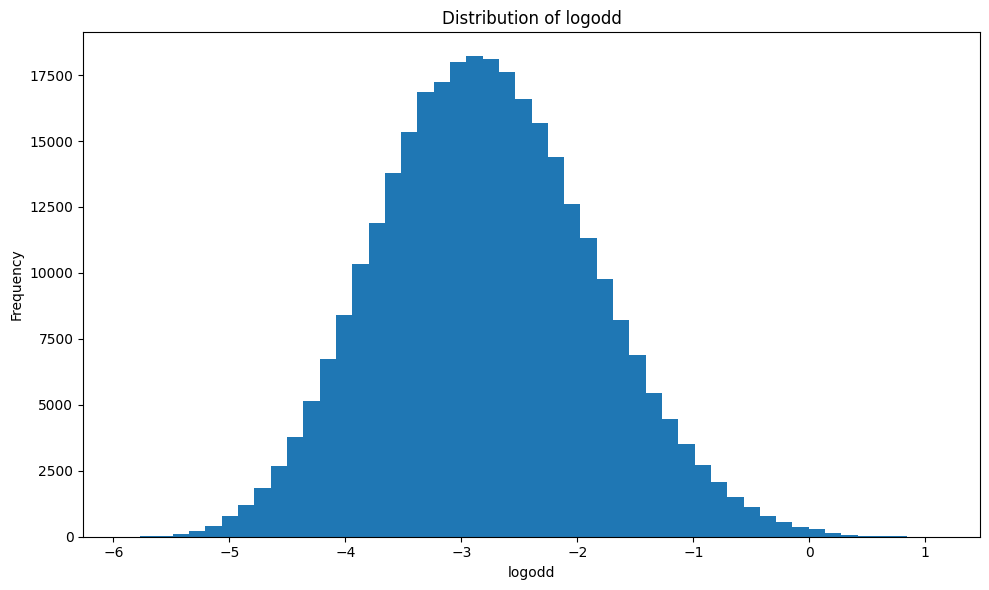

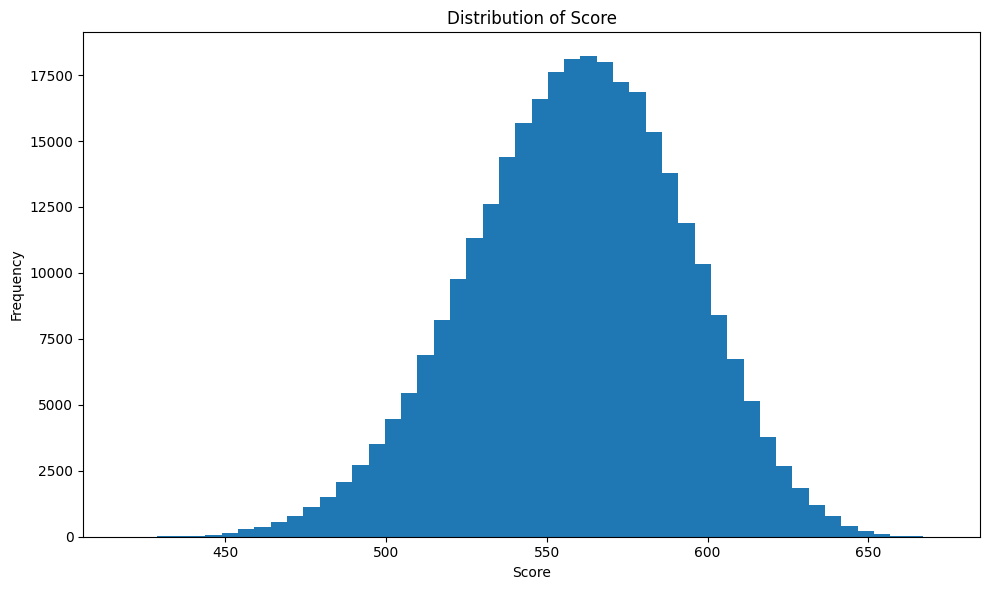

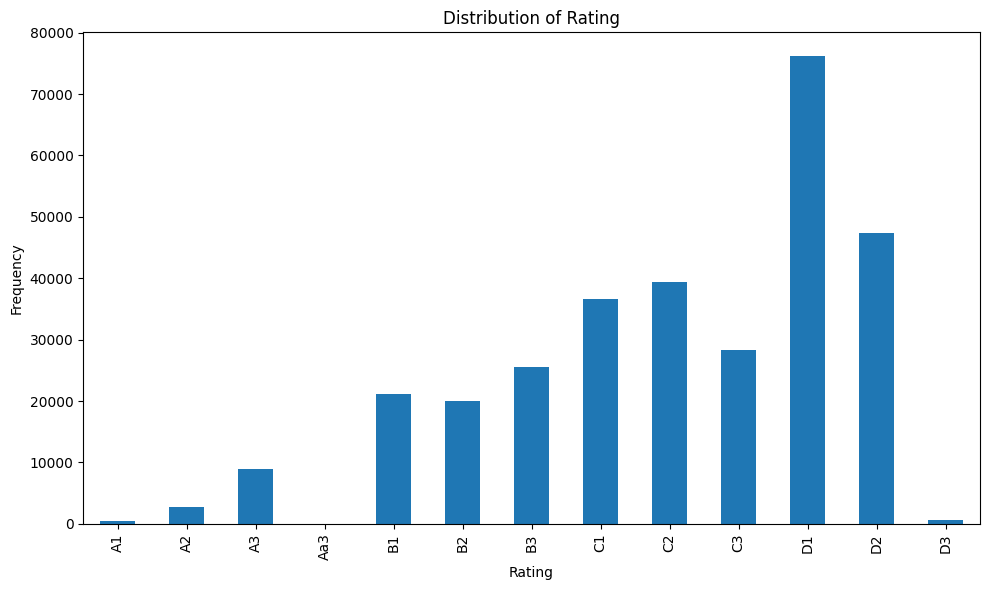

In [6]:
import matplotlib.pyplot as plt

# ── Histogram: PD, logodd, Score ─────────────────────────────────────────────
for col in ["PD", "logodd", "Score"]:
    plt.figure(figsize=(10, 6))
    
    plt.hist(df[col].dropna(), bins=50)
    
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.title(f"Distribution of {col}")
    
    plt.tight_layout()
    plt.show()


# ── Bar chart: Rating ────────────────────────────────────────────────────────
plt.figure(figsize=(10, 6))

df["Rating"].value_counts().sort_index().plot(kind="bar")

plt.xlabel("Rating")
plt.ylabel("Frequency")
plt.title("Distribution of Rating")

plt.tight_layout()
plt.show()